In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [55]:
sp.optimize?

Type:        module
String form: <module 'scipy.optimize' from '/home/miriam/lab_mat_2/lab_materia_2/.venv/lib/python3.8/site-packages/scipy/optimize/__init__.py'>
File:        ~/lab_mat_2/lab_materia_2/.venv/lib/python3.8/site-packages/scipy/optimize/__init__.py
Docstring:  
Optimization and root finding (:mod:`scipy.optimize`)

.. currentmodule:: scipy.optimize

SciPy ``optimize`` provides functions for minimizing (or maximizing)
objective functions, possibly subject to constraints. It includes
solvers for nonlinear problems (with support for both local and global
optimization algorithms), linear programing, constrained
and nonlinear least-squares, root finding, and curve fitting.

Common functions and objects, shared across different solvers, are:

.. autosummary::
   :toctree: generated/

   show_options - Show specific options optimization solvers.
   OptimizeResult - The optimization result returned by some optimizers.
   OptimizeWarning - The optimization encountered problems.



In [2]:
%matplotlib widget
plt.close('all')

In [3]:
annealing_data = "data/annealing"
data_raw = np.loadtxt(os.path.join(annealing_data, "data_20nm_annealing.txt"))


In [4]:
print(data_raw)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.966113e+03 9.900000e+37]
 [8.966498e+03 9.900000e+37]
 [8.966888e+03 9.900000e+37]]


In [5]:
#rimuovo gli zeri e i dati di overload
mask = (data_raw[:, 1] != 0) & (data_raw[:, 1] < 1e3)
data_clean = data_raw[mask]

In [6]:
print(data_clean)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.838188e+03 8.075347e+02]
 [8.838258e+03 8.089226e+02]
 [8.838327e+03 8.129338e+02]]


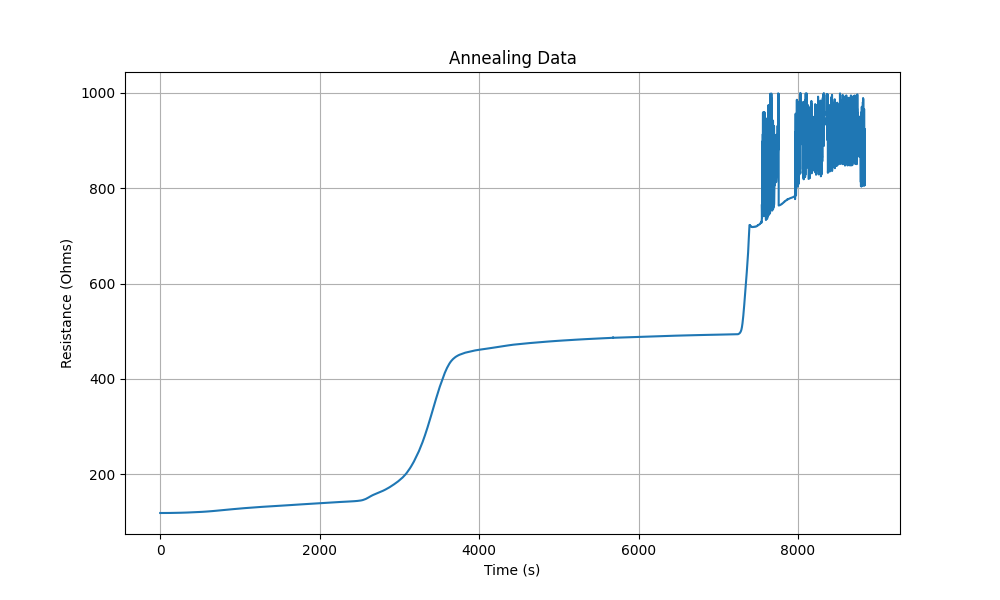

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(data_clean[:, 0], data_clean[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.grid()
plt.show()

In [8]:
#tengo solo i dati della curva percolativa
mask_perc = (data_clean[:, 0] < 7.24e3) & (data_clean[:, 1] > 0)
data_perc = data_clean[mask_perc]

In [9]:
print(data_perc)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [7.239795e+03 4.936693e+02]
 [7.239862e+03 4.936699e+02]
 [7.239931e+03 4.936702e+02]]


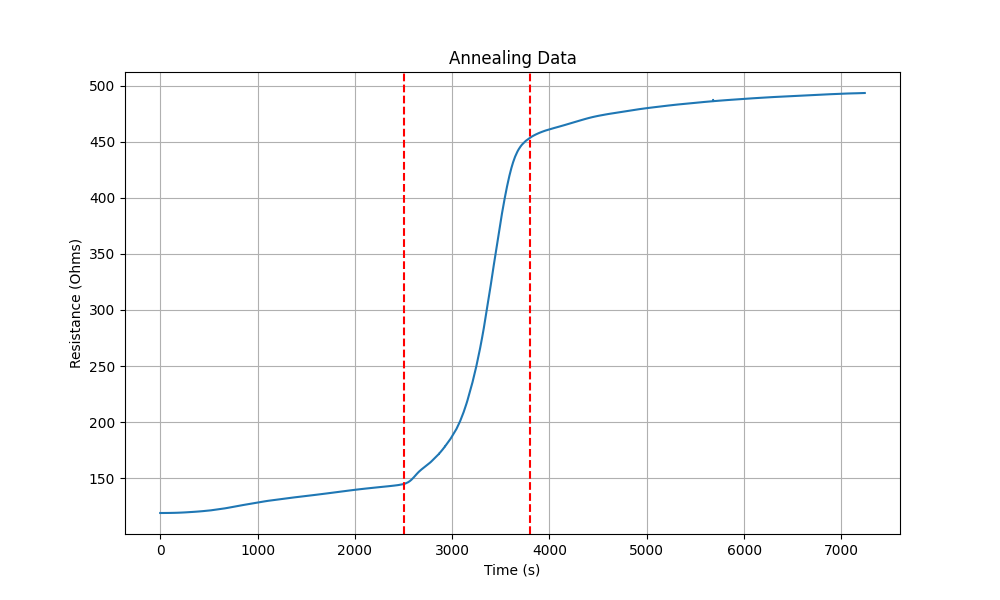

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(data_perc[:, 0], data_perc[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.axvline(2.5e3, color="red", linestyle="--")
plt.axvline(3.8e3, color="red", linestyle="--")
plt.grid()
plt.show()

Sembra esserci un aumento lineare della resistenza nel tempo prima dei 2500 s.
Nello stesso intervallo di tempo anche la T sembra avere un andamento lineare.
Verifichiamo l'ipotesi che in questo intervallo di tempo si ha una relazione di proporzionalità tra la R e la T.

In [11]:
#selezione dei dati di interesse
mask_linear = data_perc[:, 0] < 2.5e3
data_linear = data_perc[mask_linear]

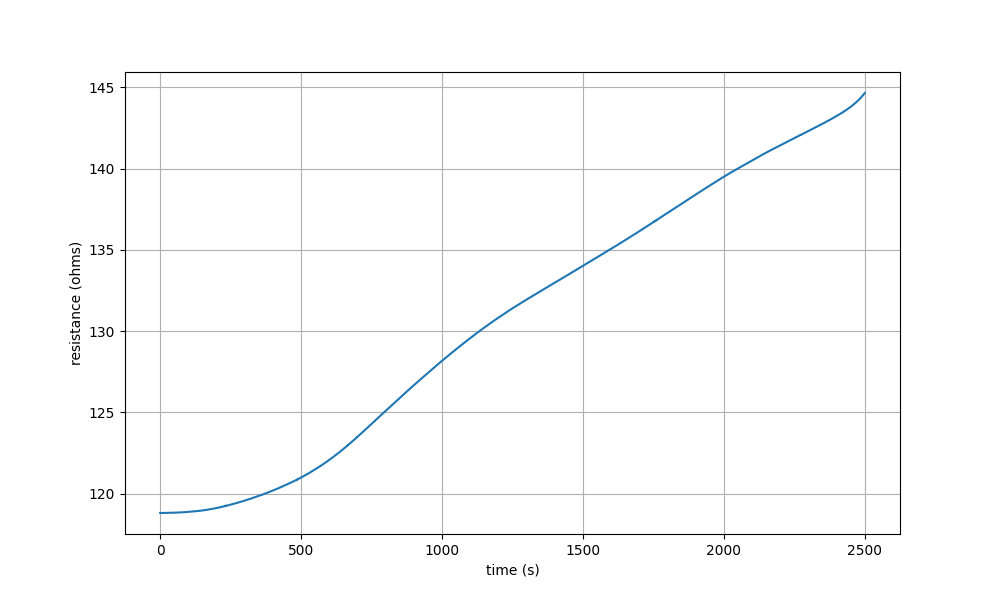

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(data_linear[:, 0], data_linear[:, 1])
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()

In [13]:
m,q = np.polyfit(data_linear[:, 0], data_linear[:, 1], 1)
print(m,q)

0.011370919415663214 116.55305797792427


In [14]:
R_fit = m*data_linear[:,0] + q
plt.plot(data_linear[:,0], R_fit)
plt.axvline(1690, color="red", linestyle="--")

In [15]:
data_time_temp_20nm = np.loadtxt(os.path.join(annealing_data, "time_temp_20nm.txt"))

temp_interp_linear_region = np.array(np.interp(data_linear[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))
temp_interp_all = np.array(np.interp(data_clean[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))
temp_interp_perc = np.array(np.interp(data_perc[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))

In [16]:
print(len(temp_interp_all))
print(len(temp_interp_perc))
print(len(data_clean[:,1]))


print(len(temp_interp_linear_region))
print(len(data_linear[:,1]))



128404
105697
128404
36482
36482


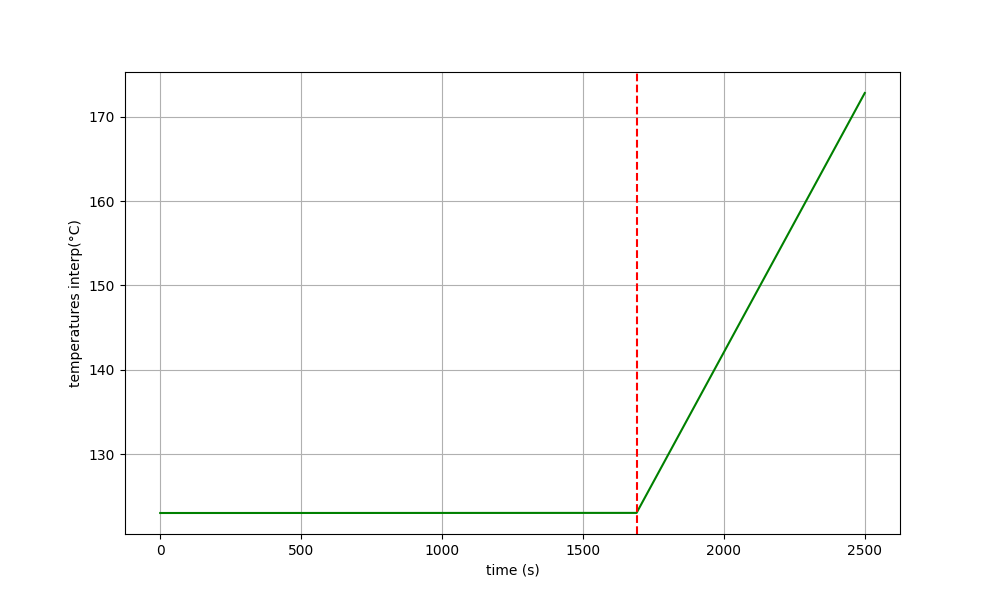

In [17]:
plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], temp_interp_linear_region, color="green")
plt.axvline(1690, color="red", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("temperatures interp(°C)")
plt.grid()
plt.show()

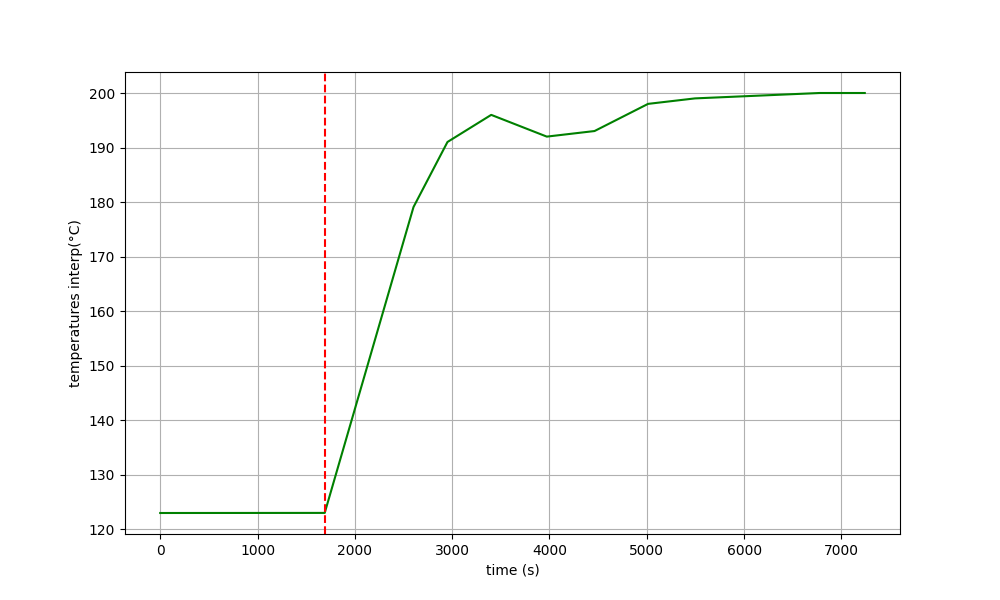

In [18]:
plt.figure(figsize=(10,6))
plt.plot(data_perc[:,0], temp_interp_perc, color="green")
#plt.plot(data_clean[:,0], temp_interp_all, color="blue")
plt.axvline(1690, color="red", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("temperatures interp(°C)")
plt.grid()
plt.show()

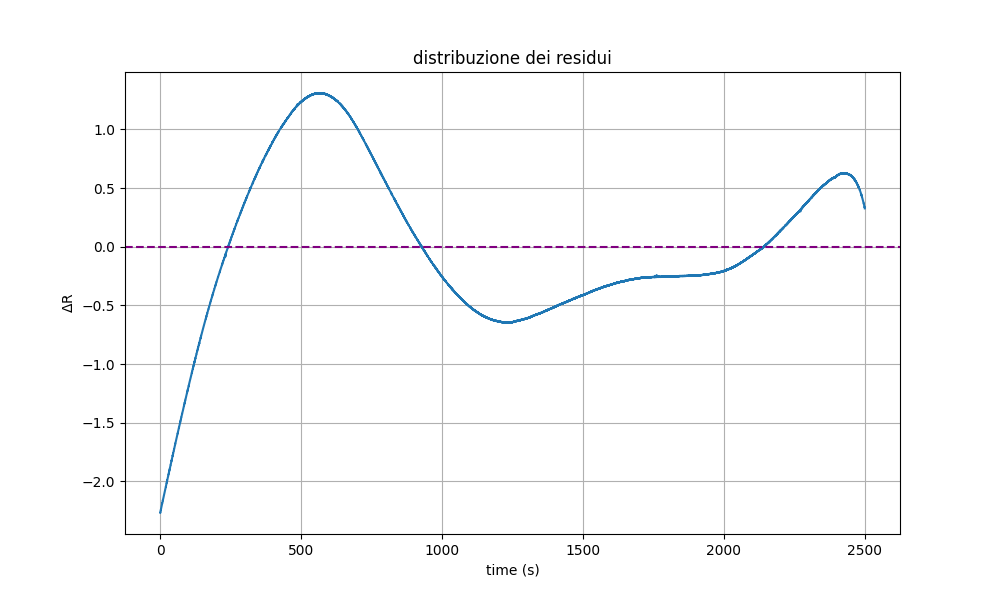

In [19]:
diff_R = R_fit - data_linear[:,1]

plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], diff_R)
plt.title("distribuzione dei residui")
plt.ylabel("$\Delta$R")
plt.xlabel("time (s)")
plt.axhline(0, color="purple", linestyle="--")
plt.grid()
plt.show()

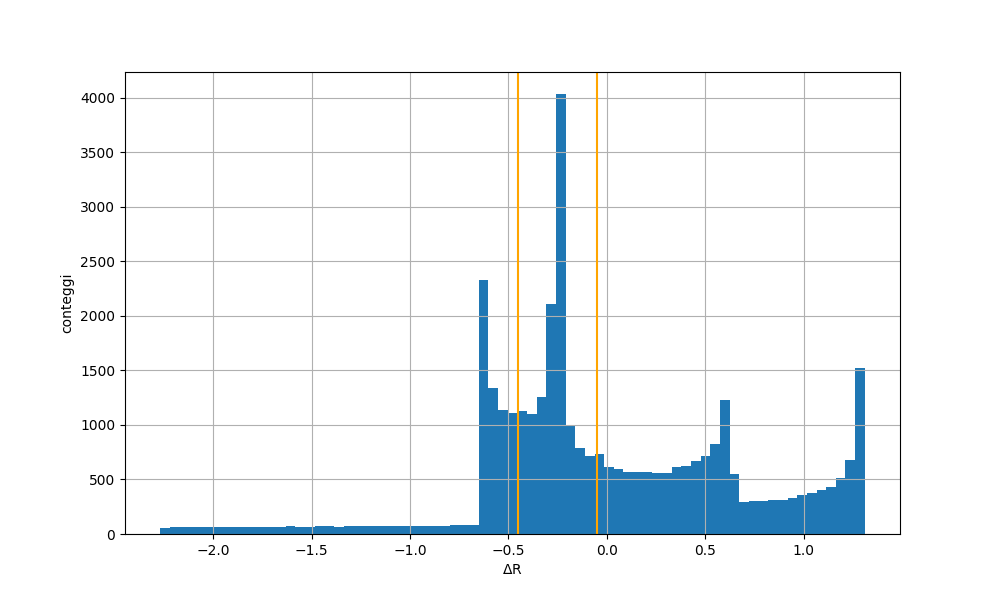

In [20]:
plt.figure(figsize=(10,6))
N = round(len(diff_R)/500) #nbins
plt.hist(diff_R, N)

mask_gaussian = (diff_R < -0.05) & (diff_R > -0.45)
diff_R_masked = diff_R[mask_gaussian]

#plt.hist(diff_R_masked, round(len((diff_R_masked/100))), color="green")
plt.axvline(-0.45, color="orange")
plt.axvline(-0.05, color="orange")
plt.ylabel("conteggi")
plt.xlabel("$\Delta$R")
plt.grid()
plt.show()

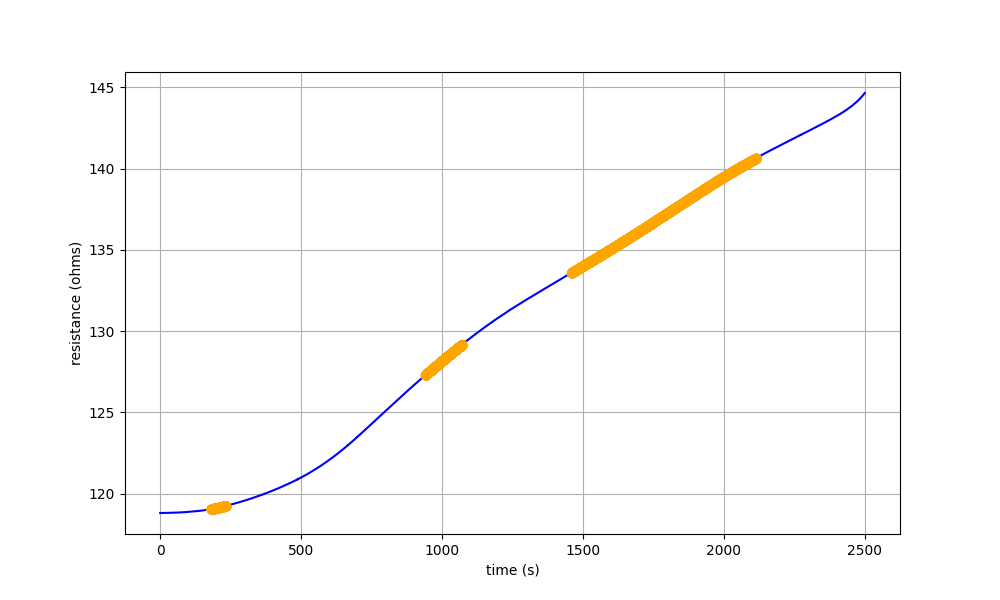

In [21]:
data_res_exp_masked = data_linear[:,1][mask_gaussian]
data_time_exp_masked = data_linear[:,0][mask_gaussian]

plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], data_linear[:,1], color="blue")
plt.plot(data_time_exp_masked, data_res_exp_masked, color="orange", linestyle="None", marker="o")
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()



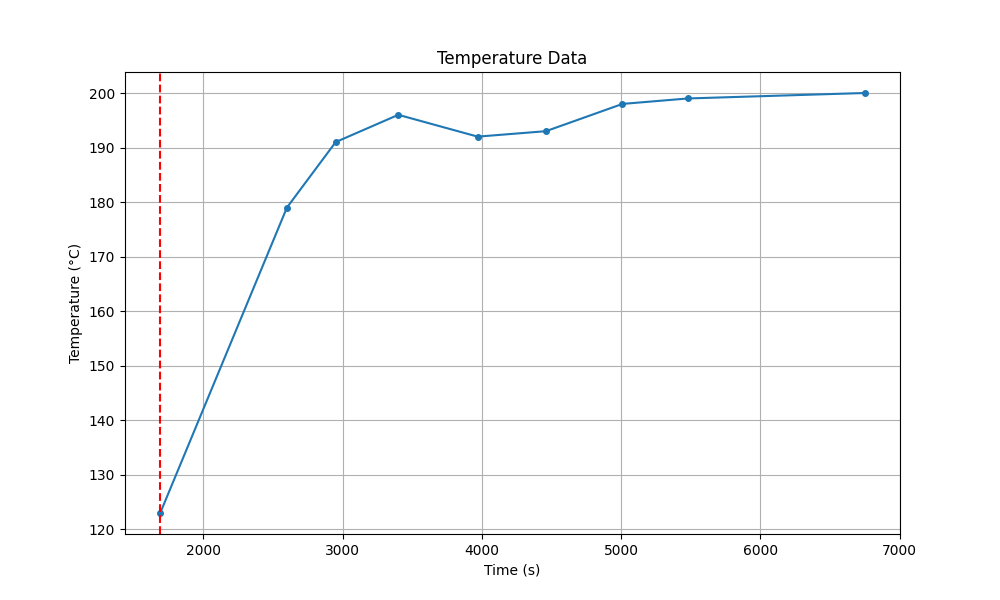

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(data_time_temp_20nm[:, 0], data_time_temp_20nm[:, 1], marker='o', markersize=4, linestyle='-')
plt.title("Temperature Data")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.axvline(1690, color="red", linestyle="--" )
plt.grid()
plt.show()

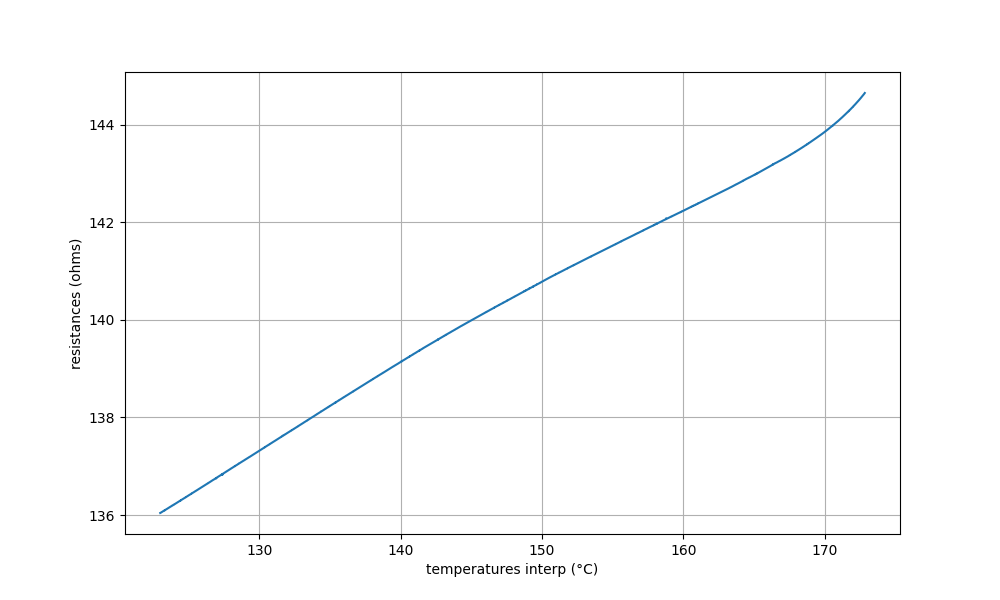

In [23]:
#plotto solo per tempi maggiori di 1690 s nella regione linere della curva percolativa
mask_over1690 = data_linear[:,0]>1690
data_linear_over1690 = data_linear[mask_over1690]
#print(len(data1_over1690))
temp_interp_linear_over1690s = temp_interp_linear_region[mask_over1690]
#print(len(temp_interp_over1690s))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_linear_over1690s, data_linear_over1690[:,1])
plt.xlabel("temperatures interp (°C)")
plt.ylabel("resistances (ohms)")
plt.grid()
plt.show()


In [24]:
m1, q1 = np.polyfit(temp_interp_linear_over1690s, data_linear_over1690[:,1], 1)
print(m1,q1)

y_fit = m1 * temp_interp_linear_over1690s +q1
plt.plot(temp_interp_linear_over1690s, y_fit, color="orange")

0.16357353331959892 116.12389111821055


81036
81036


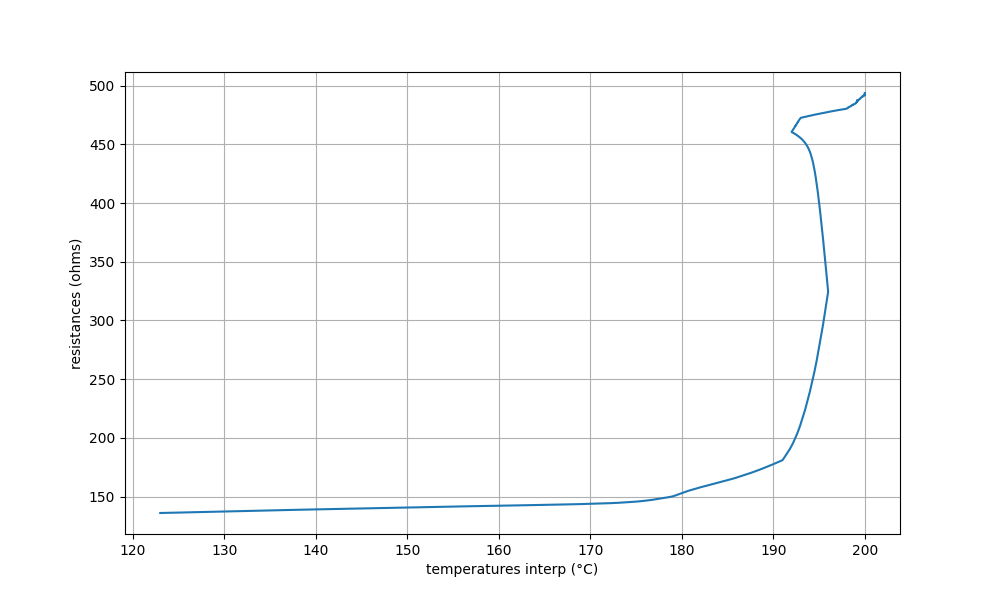

In [25]:
#prendo tutti i dati della curva percolativa per tempi maggiori di 1690 s
mask4 = data_perc[:,0]>1690
data_perc_over1690 = data_perc[mask4]
temp_interp_perc_over1690 = temp_interp_perc[mask4]
print(len(data_perc_over1690))
print(len(temp_interp_perc_over1690))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_perc_over1690, data_perc_over1690[:,1])
plt.xlabel("temperatures interp (°C)")
plt.ylabel("resistances (ohms)")
plt.grid()
plt.show()


11146
11146


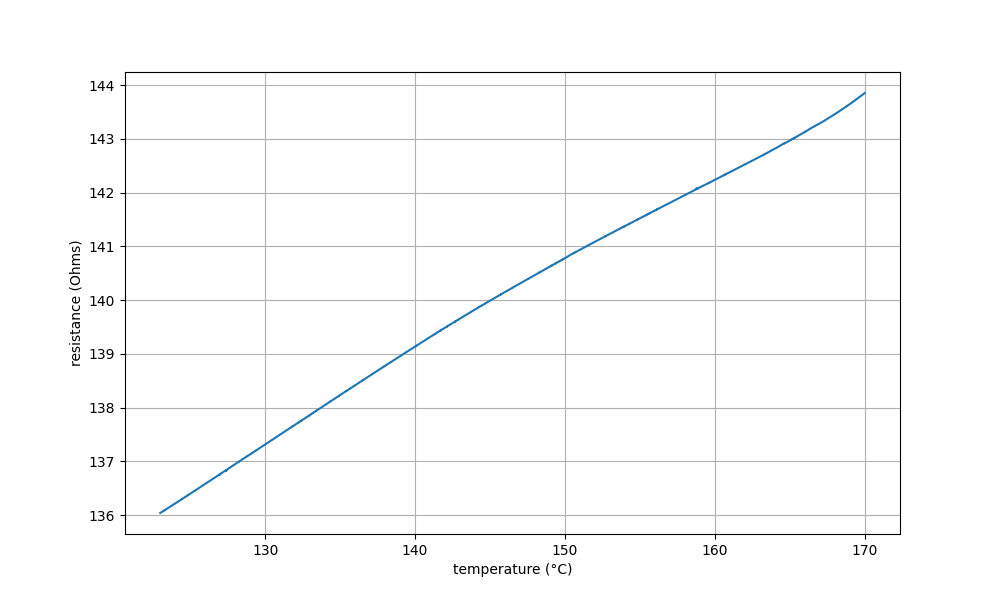

In [ ]:
#prendo i dati fino a T < 170 °C

mask5 = temp_interp_perc_over1690<170
data_perc_fit = data_perc_over1690[mask5]
temp_interp_perc_fit = temp_interp_perc_over1690[mask5]
print(len(data_perc_fit))
print(len(temp_interp_perc_fit))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_perc_fit, data_perc_fit[:,1])
plt.xlabel("temperature (°C)")
plt.ylabel("resistance (Ohms)")
plt.grid()
plt.show()


In [27]:

def f(x,alfa,q):
    R0 = data_perc_fit[0,1]
    return alfa*R0*x+q #R0 è il valore di resistenza iniziale al tempo T0


In [28]:
results = sp.optimize.curve_fit(f,temp_interp_perc_fit, data_perc_fit[:,1])
print(results)

(array([1.19890066e-03, 1.16189876e+02]), array([[ 3.19977218e-13, -6.37647838e-09],
       [-6.37647838e-09,  1.28161463e-04]]))


In [29]:
R = results[0][0]* temp_interp_perc_over1690 * data_perc_fit[0,1] + results[0][1]
print(R.shape)


(81036,)


In [30]:
devst = np.sqrt(results[1])
print(devst)  

[[5.65665288e-07            nan]
 [           nan 1.13208420e-02]]


/tmp/ipykernel_853/455797507.py:1: RuntimeWarning: invalid value encountered in sqrt
  devst = np.sqrt(results[1])


(81036, 2)
(69215, 2)
(69215,)
(69215,)


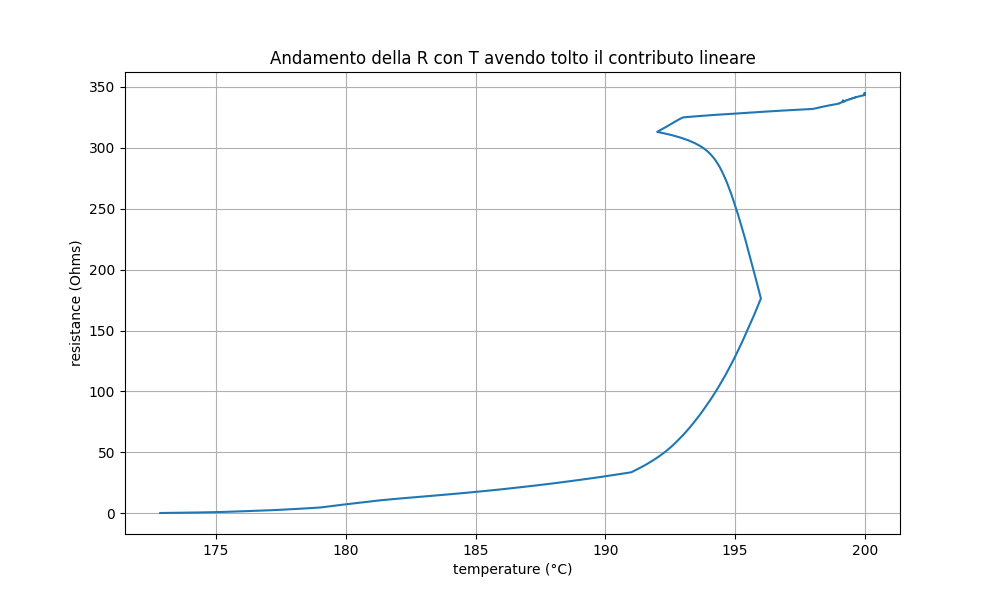

In [91]:
#tolgo il contributo lineare della R a tutti i dati di R

R_non_linear_over1690 = -R + data_perc_over1690[:,1]

mask_non_linear = data_perc_over1690[:,0]>2500
print(data_perc_over1690.shape)

data_perc_non_linear_over2500 = data_perc_over1690[mask_non_linear]
print(data_perc_non_linear_over2500.shape)

temp_interp_non_linear_over2500 = temp_interp_perc_over1690[mask_non_linear]
print(temp_interp_non_linear_over2500.shape)
R_non_linear_over2500 = R_non_linear_over1690[mask_non_linear]
print(R_non_linear_over2500.shape)

plt.figure(figsize=(10,6))
plt.plot(temp_interp_non_linear_over2500, R_non_linear_over2500)
plt.xlabel("temperature (°C)")
plt.ylabel("resistance (Ohms)")
plt.title("Andamento della R con T avendo tolto il contributo lineare")
plt.grid()
plt.show()

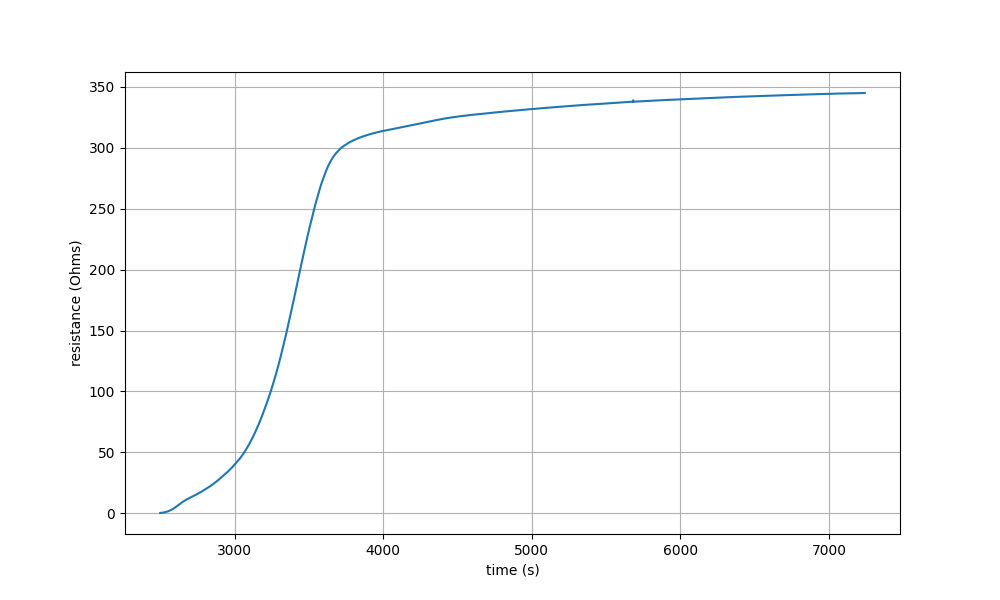

In [92]:
plt.figure(figsize=(10,6))
plt.plot(data_perc_non_linear_over2500[:,0], R_non_linear_over2500)
plt.xlabel("time (s)")
plt.ylabel("resistance (Ohms)")
plt.grid()
plt.show()

In [32]:
#calcolo errori

sigmaR = np.std(diff_R_masked)
print(sigmaR)

sigmaT = 0.5 

0.09115229704436567


In [70]:
def calcolo_errori_percentuali(res, filepath, filename):
    data_errori = np.loadtxt(os.path.join(filepath, filename))
    data_container = np.zeros((res.shape[0], data_errori.shape[1])) #tre colonne e tante righe quante sono i dati di resistenza misurati
    for i in range(len(res)):
        odg = np.floor(np.log10(np.abs(res[i,1])))
        if (res[i,1] <= 10**(odg+1)) and (res[i,1] > 10**(odg+1) - (10**(odg+1))/10) : 
            data_container[i, 0] = odg+2
        else:
            data_container[i, 0] = odg+1
        idx = data_container[i,0] - 2 
        data_container[i, 1:] = data_errori[int(idx), 1:] #riempio le ultime due colonne dell'i-esima riga
    return data_container

def exp_err (res, data_container):
    exp_err = []
    for i in range(len(res)):
        exp_err.append(res[i, 1]* data_container[i,1] + data_container[i,0] * data_container[i,2]) 
    return exp_err
    

In [93]:
error_data_container = calcolo_errori_percentuali(data_perc_non_linear_over2500, annealing_data, "dati_calcolo_exp_err.txt")
print(data_perc_non_linear_over2500.shape)
exp_err_res = np.array(exp_err(data_perc_non_linear_over2500, error_data_container))
relative_exp_err_res = exp_err_res / data_perc_non_linear_over2500[:,1]

(69215, 2)


In [97]:
print(exp_err_res.shape)


(69215,)


In [73]:
mean_exp_err_res = np.mean(exp_err_res)
print(mean_exp_err_res)

3.2171310911567974


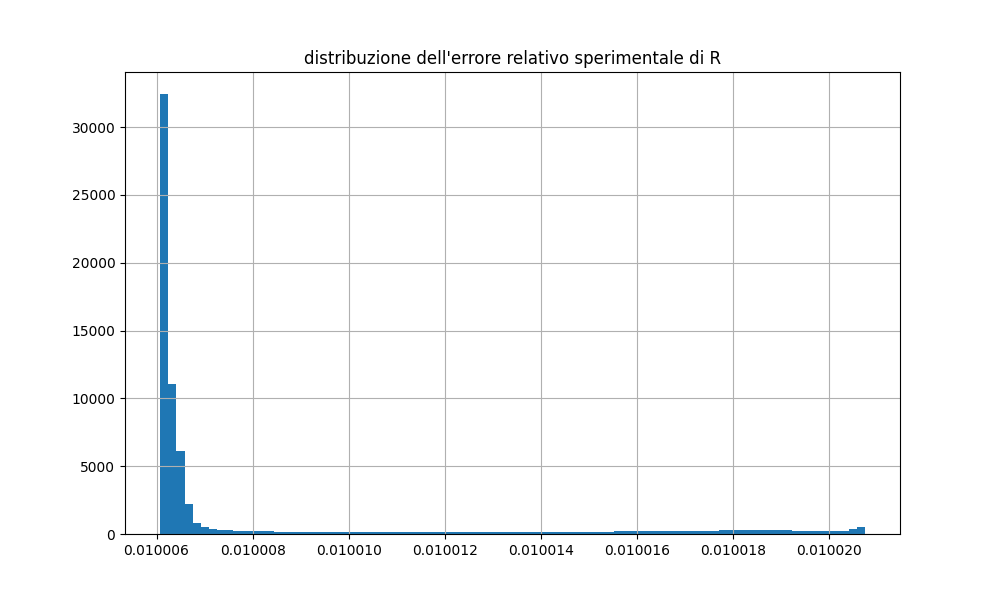

In [83]:
plt.figure(figsize=(10,6))
Nbins = round(len(relative_exp_err_res)/800)
plt.hist(relative_exp_err_res, Nbins)
plt.title("distribuzione dell'errore relativo sperimentale di R")
plt.grid()
plt.show()

In [118]:
def legge_potenza (x, a, b, c):
    return a*(x**b)

def sigmoide(x, L, k, x0):
    return (L / (1 + np.exp(-k * (x - x0)))) #+ m*x + q

# Come p0 (stime iniziali) uso: p0=[345, 0.01, 3400]



In [119]:
# Se 'errori_assoluti' è l'array con l'errore associato a ciascun punto Y
popt, pcov = sp.optimize.curve_fit(sigmoide, data_perc_non_linear_over2500[:,0], R_non_linear_over2500 , p0=[345, 0.01, 3400], sigma=exp_err_res, absolute_sigma=True)

#print(popt)
#print(pcov)

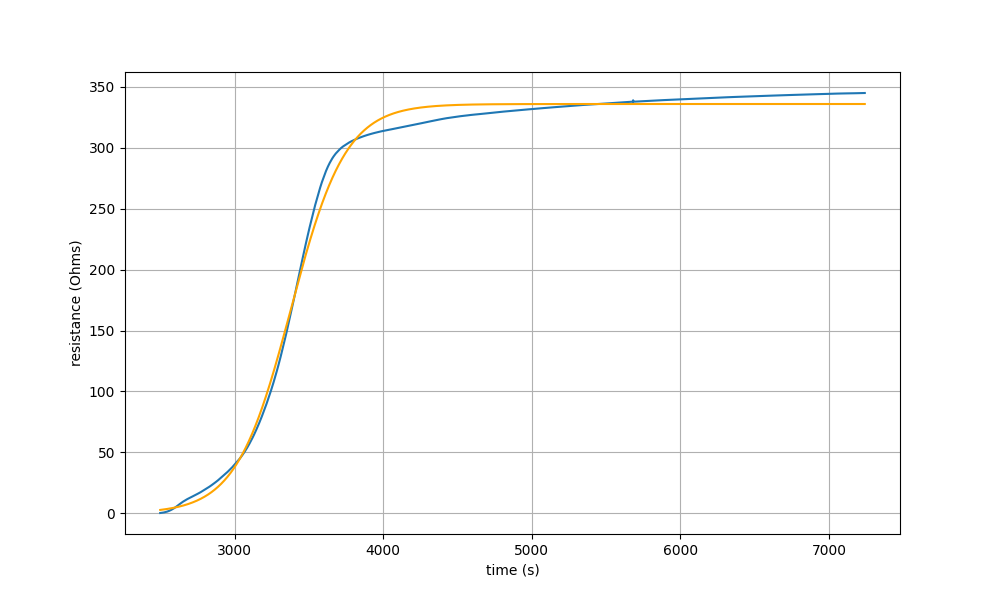

In [120]:
#R_power_fit = popt[0] * ((data_perc_non_linear_over2500[:,0])**popt[1])
R_sigmoide = popt[0] / (1 + np.exp(-popt[1] * (data_perc_non_linear_over2500[:,0] - popt[2])))

plt.figure(figsize=(10,6))
plt.plot(data_perc_non_linear_over2500[:,0], R_non_linear_over2500)
#plt.plot(data_perc_non_linear_over2500[:,0], R_power_fit, color="orange")
plt.plot(data_perc_non_linear_over2500[:,0], R_sigmoide, color="orange")

plt.xlabel("time (s)")
plt.ylabel("resistance (Ohms)")
plt.grid()
plt.show()

In [38]:
valori, occorrenze = np.unique(exp_err_res, return_counts=True)

indice_moda = np.argmax(occorrenze)
moda = valori[indice_moda]

print(moda)

1.191249
